In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math

In [27]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
#data = data[:10000]

z = data['redshift']

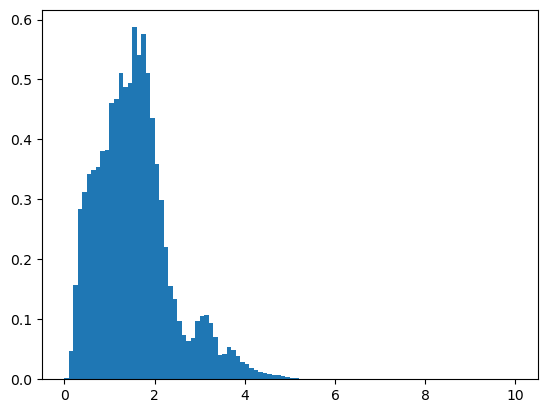

In [29]:
n, bins, patches = plt.hist(z, bins=np.linspace(0,10,101), density=True)

## Rejection sampling

In [30]:
N = 10000
ymax = np.max(n)
random_z = np.random.uniform(0,10,N)
y = np.random.uniform(0,ymax,N)

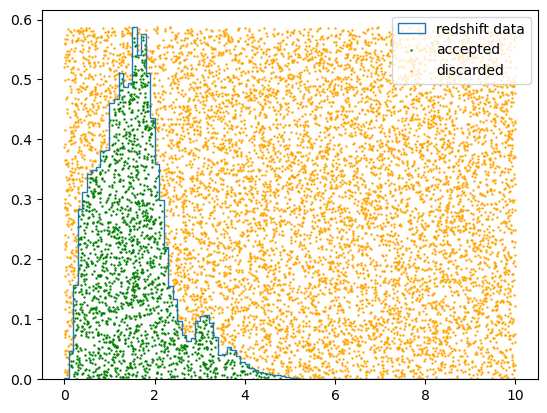

In [31]:
index = np.searchsorted(bins, random_z) -1 #restituisce array con valore dell'indice del bin in cui deve andare (-1 per far tornare gli indici del bin)
good_z = random_z[y <= n[index]] #seleziono solo i valori di y che per il dato random_z siano <= dell'altezza del bin in cui cade random_z
bad_z = random_z[y > n[index]]
good_y = y[y <= n[index]]
bad_y = y[y > n[index]]

plt.hist(z, bins=np.linspace(0,10,101), density=True, histtype='step', label = 'redshift data')
plt.scatter(good_z,good_y,s=0.5, color='green', label='accepted')
plt.scatter(bad_z, bad_y, s= 0.5, color='orange', label='discarded')
plt.legend()
plt.show()

## Inverse transform sampling

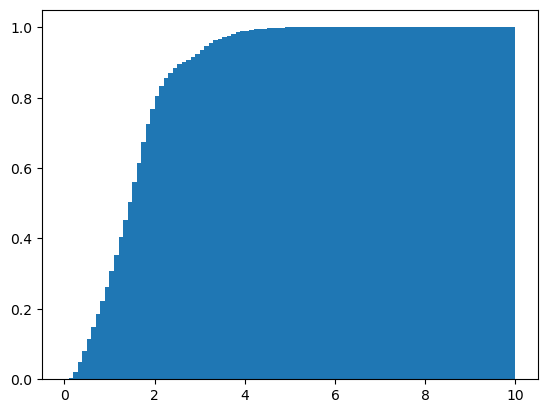

In [32]:
n_c, bins_c, patches_c = plt.hist(z, bins=np.linspace(0,10,101), density=True, cumulative=True)

In [33]:
y_c = np.random.uniform(0,1,N) #random uniformed distributed samples betwwn 0 and 1 for the cdf
index_yc = np.searchsorted(n_c,y_c) -1 #takes each random number in y_c and finds the index in the sorted array n
                                  #where that number would be inserted to maintain order
true_yc = np.random.uniform(bins_c[index_yc], bins_c[index_yc+1]) #generates a new random number for each sample drawn 
                                                              #from within the specific bin identified by the index_yc

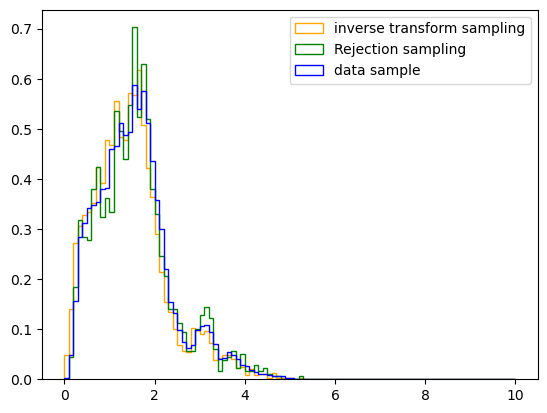

In [34]:
plt.hist(true_yc, bins=np.linspace(0,10,101), density=True, histtype='step', color='orange', label='inverse transform sampling')
plt.hist(good_z, bins=np.linspace(0,10,101), density=True, histtype='step', color='green', label='Rejection sampling')
plt.hist(z, bins=np.linspace(0,10,101), density=True, histtype='step', color='blue', label='data sample')
plt.legend()
plt.show()

In [58]:
import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

at the beginning (lower redshift) the distribution of quasars follows the histogram (because i can se all af them) but at higer redshift starts to drop because I can't see all of them (very difficult)